# LAB 2: Estadística Descriptiva Básica 2-Series de Tiempo

### Víctor Palacios Mena (1017271469)

## Series de tiempo

1. Importación de Librerías y Carga de Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fitter import Fitter, get_common_distributions, get_distributions

# URL del dataset (Se asume una URL de GitHub que contenga el CSV)
# Nota: Asegúrate de que la URL apunte al archivo "raw"
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv" 
df = pd.read_csv(url)

# Visualizar las primeras filas
df.head()

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


2. Definición del Índice y Preparación del Tiempo

Para trabajar con series de tiempo, es fundamental que la columna que representa el tiempo sea el índice del DataFrame y tenga el formato datetime.

In [2]:
# Convertir la columna 'time' a formato datetime
df['time'] = pd.to_datetime(df['time'])

# Definir como índice la columna 'time'
df.set_index('time', inplace=True)

# Mostrar el nuevo índice
df.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


3. Información del DataFrame y Limpieza

Obtenemos un resumen de la estructura del DataFrame y verificamos la presencia de valores nulos o inconsistentes.

In [3]:
# información general del dataframe
print("--- Información del DataFrame ---")
df.info()

# Determino si hay valores null o NaN
print("\n--- Conteo de valores nulos por columna ---")
print(df.isnull().sum())

--- Información del DataFrame ---
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB

--- Conteo de valores nulos por columna ---
Unnamed: 0            0
open                  0
hig

4. Selección de Datos y Formato Pascal Case

De acuerdo con los requerimientos, trabajaremos únicamente con la columna de precio de cierre. Aplicaremos la notación Pascal Case (Primera letra en mayúscula) al nombre de la columna.

In [4]:
# Selección solo la columna de cierre (asumiendo que originalmente se llama 'close' o 'Close')
# Forzamos el nombre a Pascal Case: 'Close'
df = df[['close']].rename(columns={'close': 'Close'})

# Mostrar las primeras filas del dataframe resultante
df.head()

,Close
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


5. Análisis de Diferencias de Precio (DiffPrice)

Calculamos la diferencia de precio entre horas consecutivas. Esta métrica es crucial en finanzas para analizar la volatilidad y los retornos.

In [5]:
# Determinar la diferencia de precio entre horas
df['DiffPrice'] = df['Close'].diff()

# Eliminar el primer valor (NaN) que resulta del cálculo de la diferencia
df.dropna(inplace=True)

# El dataframe ahora solo tiene las columnas 'Close' y 'DiffPrice' con el tiempo como índice
df.head()

,Close,DiffPrice
time,,
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
2022-07-25 18:00:00,1.02099,-0.00082


6. Visualización de los Datos

Construimos un histograma para observar la distribución de los cambios de precio (DiffPrice).

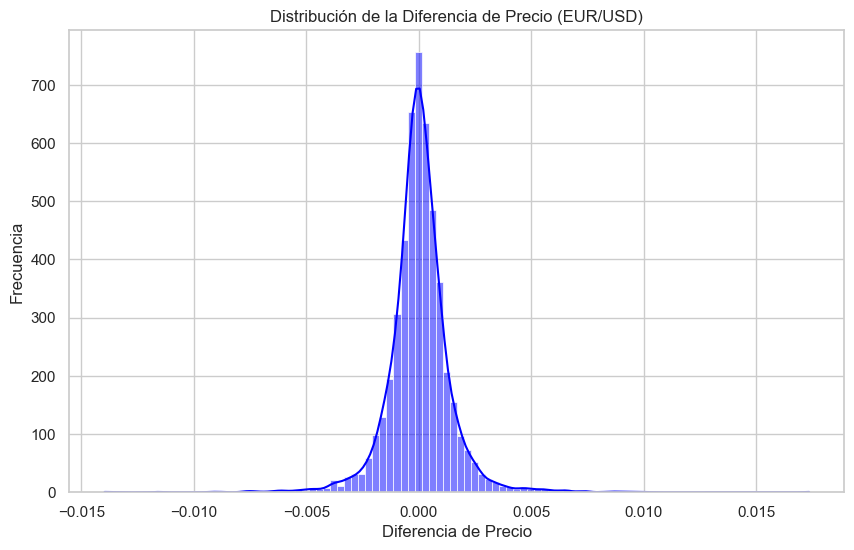

In [6]:
# Configuración de estilo
sns.set(style="whitegrid")

# Construcción del histograma
plt.figure(figsize=(10, 6))
sns.histplot(df['DiffPrice'], kde=True, color='blue', bins=100)
plt.title('Distribución de la Diferencia de Precio (EUR/USD)')
plt.xlabel('Diferencia de Precio')
plt.ylabel('Frecuencia')
plt.show()

7. Ajuste de Distribuciones Estadísticas con Fitter

Utilizaremos la librería fitter para identificar cuál de las distribuciones sugeridas se ajusta mejor a los datos de la columna DiffPrice.

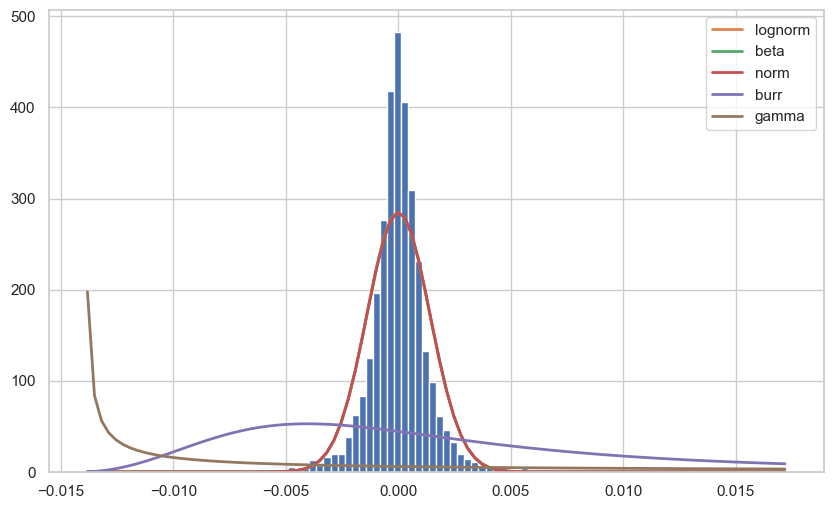

In [7]:
# Preparar los datos (convertir la serie a un array de numpy)
data = df['DiffPrice'].values

# Configurar el objeto Fitter con las distribuciones solicitadas
f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])

# Ejecutar el ajuste
f.fit()

# Mostrar el resumen de los resultados (ordenado por mejor ajuste)
plt.figure(figsize=(10, 6))
f.summary()
plt.show()

7.1. Identificación de la Mejor Distribución

A continuación, extraemos formalmente la distribución que obtuvo el menor Error Cuadrático Medio (MSE).

In [8]:
# Identificamos la mejor distribución con el error cuadrático medio
best_dist = f.get_best(method = 'sumsquare_error')
print("La mejor distribución es:")
print(best_dist)

La mejor distribución es:
{'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}


7.2. Parámetros de la Distribución Beta

Específicamente, consultamos los parámetros obtenidos para la distribución Beta.

In [9]:
# Identificamos parámetros de la distribución beta
params_beta = f.fitted_param["beta"]
print("Parámetros de la distribución Beta (a, b, loc, scale):")
print(params_beta)

Parámetros de la distribución Beta (a, b, loc, scale):
(np.float64(14613.868594375072), np.float64(27361.660606098114), np.float64(-0.2096488866774875), np.float64(0.6022115067129248))


8. Exploración de todas las Distribuciones

La librería fitter permite no solo usar un subconjunto, sino probar todas las distribuciones disponibles para encontrar la que mejor represente los datos.

In [10]:
# Ver todas las distribuciones disponibles en la librería
all_dist = get_distributions()
print(f"Existen {len(all_dist)} distribuciones disponibles.")

# Ajustar a las mejores distribuciones (Nota: Probar TODAS puede ser costoso computacionalmente)
# En este caso, buscaremos la mejor de todas las disponibles
f_all = Fitter(data, timeout=60) # timeout para evitar esperas excesivas
f_all.fit()

print("\n--- Mejor distribución absoluta ---")
print(f_all.get_best(method = 'sumsquare_error'))

Existen 115 distribuciones disponibles.

--- Mejor distribución absoluta ---
{'johnsonsu': {'a': np.float64(-0.020654532350683215), 'b': np.float64(1.049797421216857), 'loc': np.float64(-1.5194909287993722e-05), 'scale': np.float64(0.0008808828671326262)}}


9. Filtrado de Datos para el Año 2023

Aislamos los datos correspondientes únicamente al año 2023 para realizar un análisis más específico sobre el periodo más reciente.

In [11]:
# Asegurarnos que el índice sea datetime (si no se hizo antes)
df.index = pd.to_datetime(df.index)

# Seleccionar solo los datos del 2023
df_2023 = df.loc['2023'].copy()

print(f"Registros en 2023: {len(df_2023)}")
df_2023.head()

Registros en 2023: 2278


,Close,DiffPrice
time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


10. Agrupación y Promedios por Periodicidad

El uso de pd.Grouper es una herramienta poderosa para resumir series de tiempo. Calcularemos el precio promedio de cierre para diferentes ventanas temporales.

In [12]:
# Como 'time' es el índice, usamos freq directamente en el índice
# Promedio cada 15 días
mean_15d = df_2023.groupby(pd.Grouper(freq='15D')).mean()
print("--- Promedio cada 15 días ---")
print(mean_15d['Close'].head())

# Promedio semanal (1 semana)
mean_1W = df_2023.groupby(pd.Grouper(freq='1W')).mean()
print("\n--- Promedio semanal ---")
print(mean_1W['Close'].head())

# Promedio mensual (1 mes)
mean_1M = df_2023.groupby(pd.Grouper(freq='MS')).mean() # MS = Month Start
print("\n--- Promedio mensual ---")
print(mean_1M['Close'].head())

--- Promedio cada 15 días ---
time
2023-01-02    1.069361
2023-01-17    1.085565
2023-02-01    1.077679
2023-02-16    1.063150
2023-03-03    1.063186
Freq: 15D, Name: Close, dtype: float64

--- Promedio semanal ---
time
2023-01-08    1.059972
2023-01-15    1.076002
2023-01-22    1.082041
2023-01-29    1.088414
2023-02-05    1.089281
Freq: W-SUN, Name: Close, dtype: float64

--- Promedio mensual ---
time
2023-01-01    1.077463
2023-02-01    1.071167
2023-03-01    1.070874
2023-04-01    1.096051
2023-05-01    1.098980
Freq: MS, Name: Close, dtype: float64


11. Histogramas Mensuales para el año 2023

Para observar cómo cambia la distribución de la volatilidad (DiffPrice) mes a mes, iteramos sobre los grupos generados por el agrupador mensual.

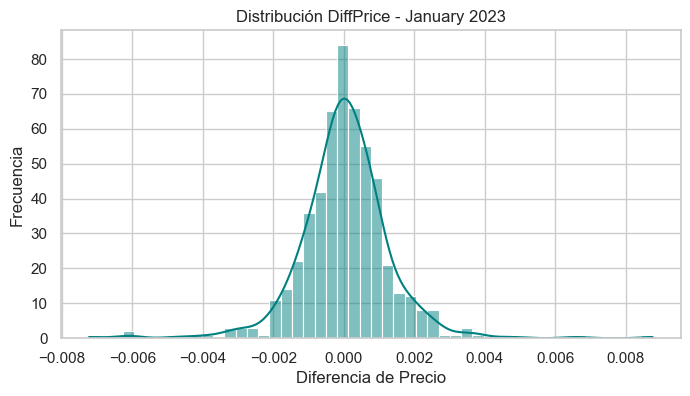

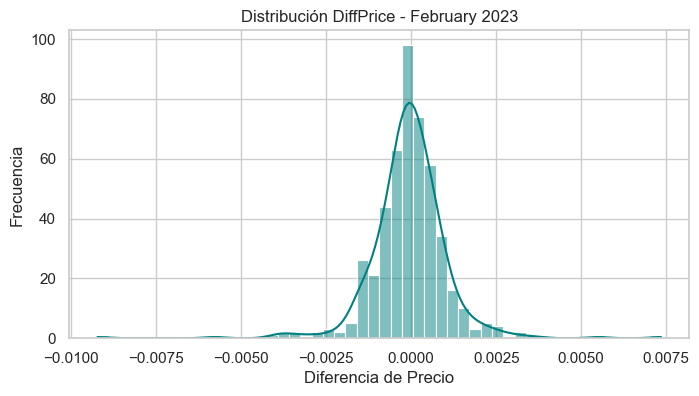

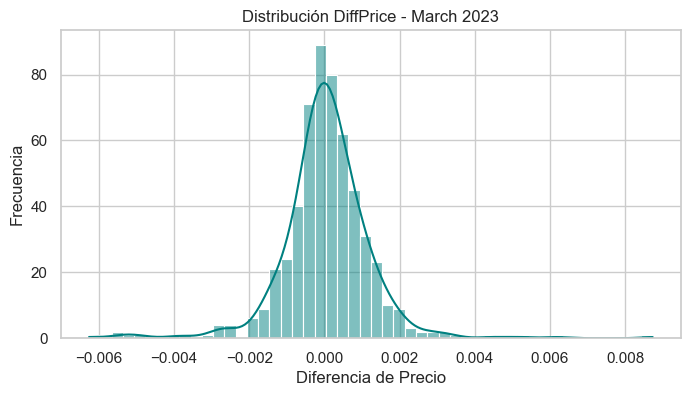

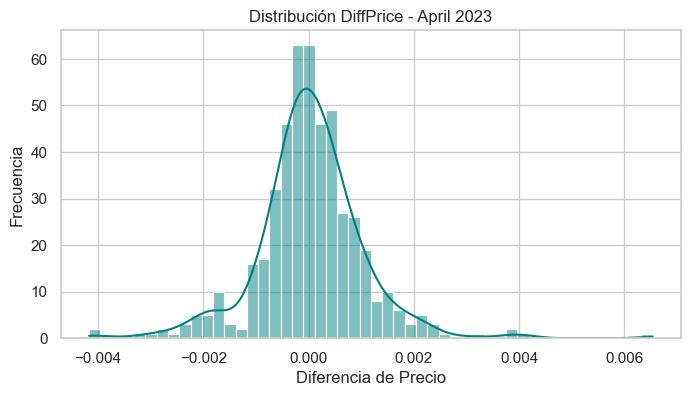

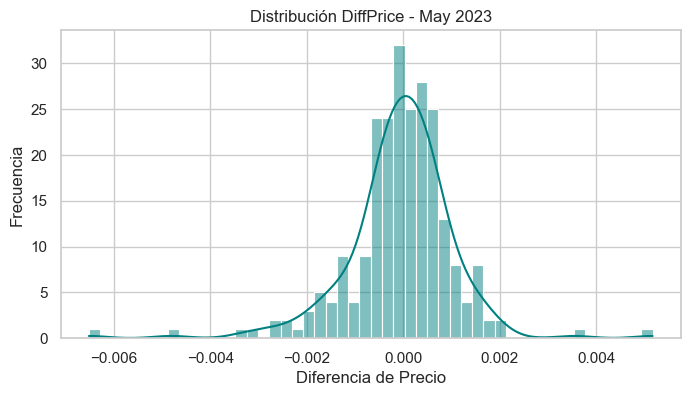

In [13]:
# Agrupar los datos de 2023 por mes
grupos_mensuales = df_2023.groupby(pd.Grouper(freq='MS'))

# Iterar sobre cada mes y construir su histograma
for nombre, grupo in grupos_mensuales:
    # Verificar que el grupo tenga datos
    if not grupo.empty:
        plt.figure(figsize=(8, 4))
        sns.histplot(grupo['DiffPrice'], kde=True, color='teal', bins=50)
        
        # Formatear el título con el nombre del mes y año
        titulo_mes = nombre.strftime('%B %Y')
        plt.title(f'Distribución DiffPrice - {titulo_mes}')
        plt.xlabel('Diferencia de Precio')
        plt.ylabel('Frecuencia')
        plt.show()

## Análisis de datos 

### Breast Cancer Wisconsin (Diagnostic)

1. Carga de Datos desde la Web

El dataset se encuentra alojado en el repositorio de UCI Machine Learning. Dado que el archivo original no tiene encabezados, los definiremos manualmente.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# URL del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Nombres base de las características
column_names = ['Id', 'Diagnosis']
features = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 
            'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

# El dataset tiene 3 versiones de cada característica: Mean, Se (Standard Error) y Worst.
for suffix in ['Mean', 'Se', 'Worst']:
    for feat in features:
        column_names.append(f"{feat}{suffix}")

# Leer los datos
df = pd.read_csv(url, names=column_names)
df.head()

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2. Renombrar Columnas en PascalCase

Aunque ya definimos los nombres en PascalCase al cargar el archivo, aseguraremos que todas las columnas sigan este estándar.

In [15]:
# Función para asegurar PascalCase (en caso de que vinieran de otra fuente)
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '', name) for name in df.columns] 
# Nota: En nuestro caso ya están formateadas como 'RadiusMean', etc.
print(df.columns)

Index(['Id', 'Diagnosis', 'RadiusMean', 'TextureMean', 'PerimeterMean',
       'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean',
       'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'RadiusSe',
       'TextureSe', 'PerimeterSe', 'AreaSe', 'SmoothnessSe', 'CompactnessSe',
       'ConcavitySe', 'ConcavePointsSe', 'SymmetrySe', 'FractalDimensionSe',
       'RadiusWorst', 'TextureWorst', 'PerimeterWorst', 'AreaWorst',
       'SmoothnessWorst', 'CompactnessWorst', 'ConcavityWorst',
       'ConcavePointsWorst', 'SymmetryWorst', 'FractalDimensionWorst'],
      dtype='str')


3. Exploración Inicial del DataFrame

Obtenemos una visión general de la estructura y estadísticas de los datos.

In [16]:
print("--- Información General ---")
df.info()

print("\n--- Primeras Filas ---")
display(df.head())

print("\n--- Últimas Filas ---")
display(df.tail())

print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     569 non-null    int64  
 1   Diagnosis              569 non-null    str    
 2   RadiusMean             569 non-null    float64
 3   TextureMean            569 non-null    float64
 4   PerimeterMean          569 non-null    float64
 5   AreaMean               569 non-null    float64
 6   SmoothnessMean         569 non-null    float64
 7   CompactnessMean        569 non-null    float64
 8   ConcavityMean          569 non-null    float64
 9   ConcavePointsMean      569 non-null    float64
 10  SymmetryMean           569 non-null    float64
 11  FractalDimensionMean   569 non-null    float64
 12  RadiusSe               569 non-null    float64
 13  TextureSe              569 non-null    float64
 14  PerimeterSe            569 non-null    fl

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Últimas Filas ---


,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039



--- Estadísticas Descriptivas ---


,Id,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


4. Gestión de Valores Nulos

In [17]:
# Contabilizar nulos
null_counts = df.isnull().sum()
print("Valores nulos por columna:")
print(null_counts[null_counts > 0])

# Estrategia de reemplazo (Teórica, ya que este dataset suele estar limpio):
# 1. Si son pocos: Eliminar filas con df.dropna().
# 2. Si son numéricos: Imputar con la media o mediana (df.fillna(df.mean())).
# 3. Si son categóricos: Imputar con la moda.

Valores nulos por columna:
Series([], dtype: int64)


5. Identificación de Valores Únicos en el Target
La columna Diagnosis contiene las etiquetas de clasificación.

In [18]:
valores_unicos = df['Diagnosis'].unique()
print(f"Los valores únicos en la columna de diagnóstico son: {valores_unicos}")

Los valores únicos en la columna de diagnóstico son: <StringArray>
['M', 'B']
Length: 2, dtype: str


6. Conteo de Casos (Benigno vs Maligno)

Visualizamos la distribución de las clases para entender si el dataset está balanceado.

C:\Users\HOME\AppData\Local\Temp\ipykernel_8896\3273189145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', palette={'B': 'blue', 'M': 'orange'})


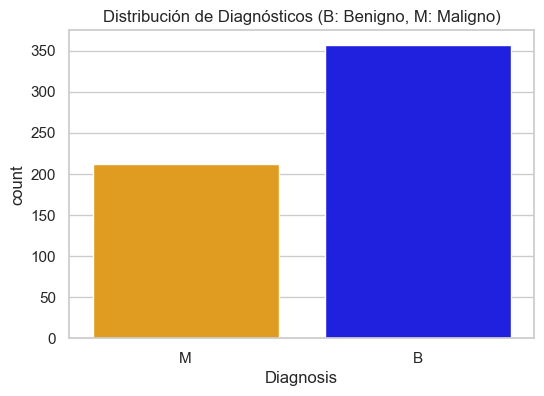

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Diagnosis', palette={'B': 'blue', 'M': 'orange'})
plt.title('Distribución de Diagnósticos (B: Benigno, M: Maligno)')
plt.show()

7. Codificación Numérica del Diagnóstico

Creamos una columna numérica para facilitar cálculos estadísticos y modelos futuros.

In [20]:
# Mapeo: B -> 0, M -> 1
df['DiagnosisNumeric'] = df['Diagnosis'].map({'B': 0, 'M': 1})
df[['Diagnosis', 'DiagnosisNumeric']].head()

,Diagnosis,DiagnosisNumeric
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


8. Normalización de Datos (Z-Score)

Normalizamos las características para que tengan media 0 y desviación estándar 1.

In [21]:
# Seleccionamos solo columnas numéricas (excluyendo ID y el Target)
cols_to_norm = df.select_dtypes(include=[np.number]).columns.drop(['Id', 'DiagnosisNumeric'])

# Aplicar formula: (x - mean) / std
df_norm = df.copy()
df_norm[cols_to_norm] = (df[cols_to_norm] - df[cols_to_norm].mean()) / df[cols_to_norm].std()

df_norm.head()

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,DiagnosisNumeric
0,842302,M,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,...,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,1
1,842517,M,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,...,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,1
2,84300903,M,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,...,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,1
3,84348301,M,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,...,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,1
4,84358402,M,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,...,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,1


9. Agrupación de Características por Patrón

Utilizaremos expresiones regulares o startswith para agrupar las columnas que comparten la misma raíz (Radius, Texture, etc.) y calcular su promedio general.

In [22]:
# Lista de raíces de características
base_features = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 
                 'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

print("Promedio general por tipo de característica:")
for feature in base_features:
    # Seleccionar columnas que comiencen con la raíz
    relevant_cols = [col for col in df.columns if col.startswith(feature)]
    avg_value = df[relevant_cols].mean().mean()
    print(f"{feature}: {avg_value:.4f}")

Promedio general por tipo de característica:
Radius: 10.2672
Texture: 15.3946
Perimeter: 67.3654
Area: 525.2698
Smoothness: 0.0786
Compactness: 0.1280
Concavity: 0.1310
ConcavePoints: 0.0584
Symmetry: 0.1639
FractalDimension: 0.0502


10. Histograma de RadiusMean por Diagnóstico

Comparamos la distribución del radio promedio entre casos benignos y malignos.

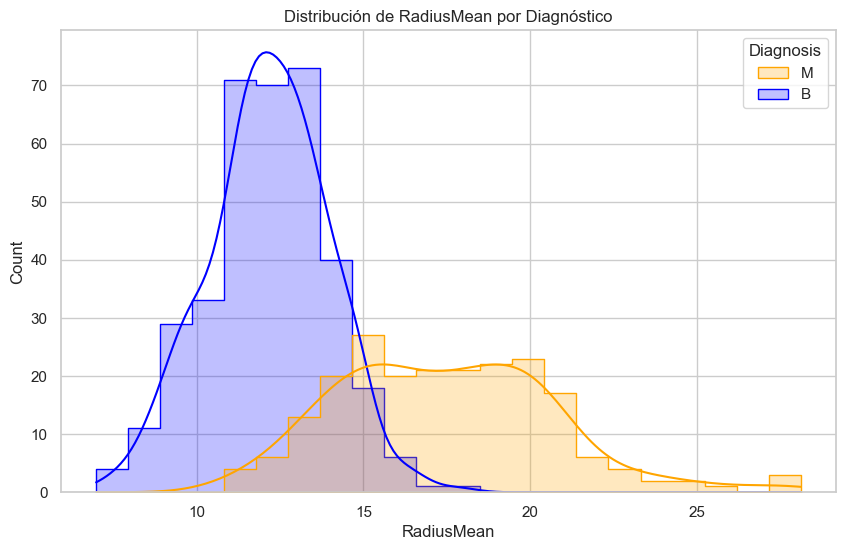

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='RadiusMean', hue='Diagnosis', kde=True, 
             palette={'B': 'blue', 'M': 'orange'}, element="step")
plt.title('Distribución de RadiusMean por Diagnóstico')
plt.show()

11. Gráfico de Violín para Múltiples Características

Para comparar escalas, utilizaremos los datos normalizados y el método melt.

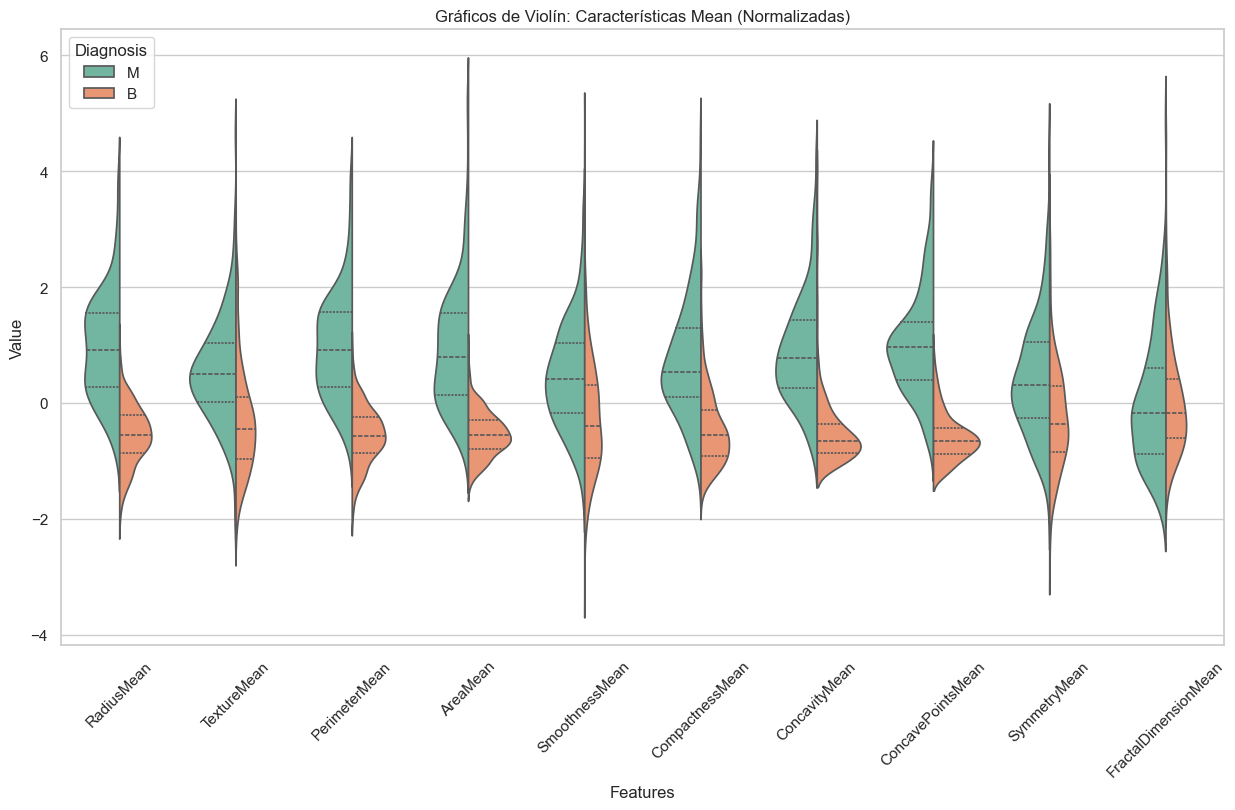

In [24]:
# Seleccionamos las primeras 10 características (las 'Mean')
features_mean = [col for col in df_norm.columns if 'Mean' in col][:10]

# Transformar el dataframe para Seaborn
data_melted = pd.melt(df_norm, id_vars="Diagnosis", 
                      value_vars=features_mean, 
                      var_name="Features", value_name="Value")

plt.figure(figsize=(15,8))
sns.violinplot(x="Features", y="Value", hue="Diagnosis", 
               data=data_melted, split=True, inner="quart", palette='Set2')
plt.xticks(rotation=45)
plt.title('Gráficos de Violín: Características Mean (Normalizadas)')
plt.show()

12. Detección y Eliminación de Outliers en RadiusMean

Identificamos valores atípicos mediante Boxplot y el Rango Intercuartílico (IQR).

<Figure size 1000x500 with 0 Axes>

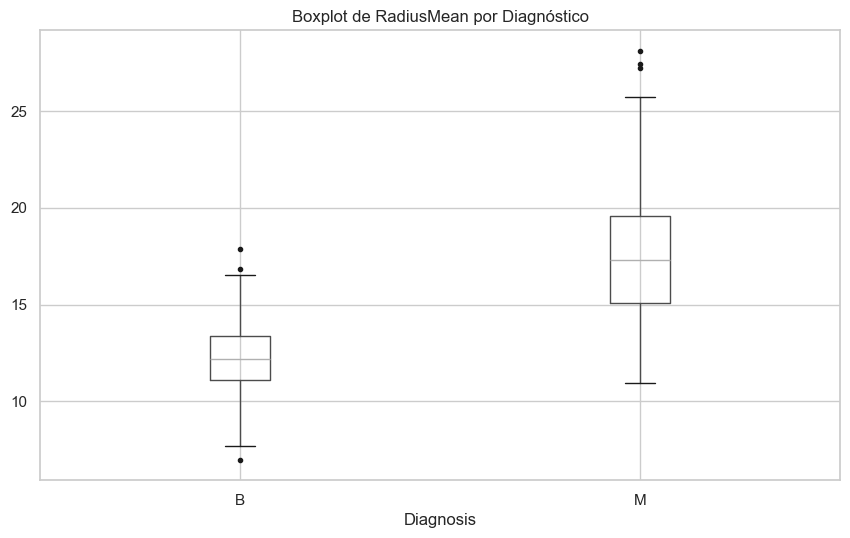

Registros originales: 569
Registros tras eliminar outliers en RadiusMean: 555


In [25]:
# Visualización inicial
plt.figure(figsize=(10,5))
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(10,6))
plt.title('Boxplot de RadiusMean por Diagnóstico')
plt.suptitle("") # Eliminar título automático de pandas
plt.show()

# Cálculo de IQR para eliminar outliers
Q1 = df['RadiusMean'].quantile(0.25)
Q3 = df['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar el dataframe
df_clean = df[~((df['RadiusMean'] < lower_bound) | (df['RadiusMean'] > upper_bound))]

print(f"Registros originales: {len(df)}")
print(f"Registros tras eliminar outliers en RadiusMean: {len(df_clean)}")

13. Matriz de Correlación

Analizamos la relación lineal entre las variables principales.

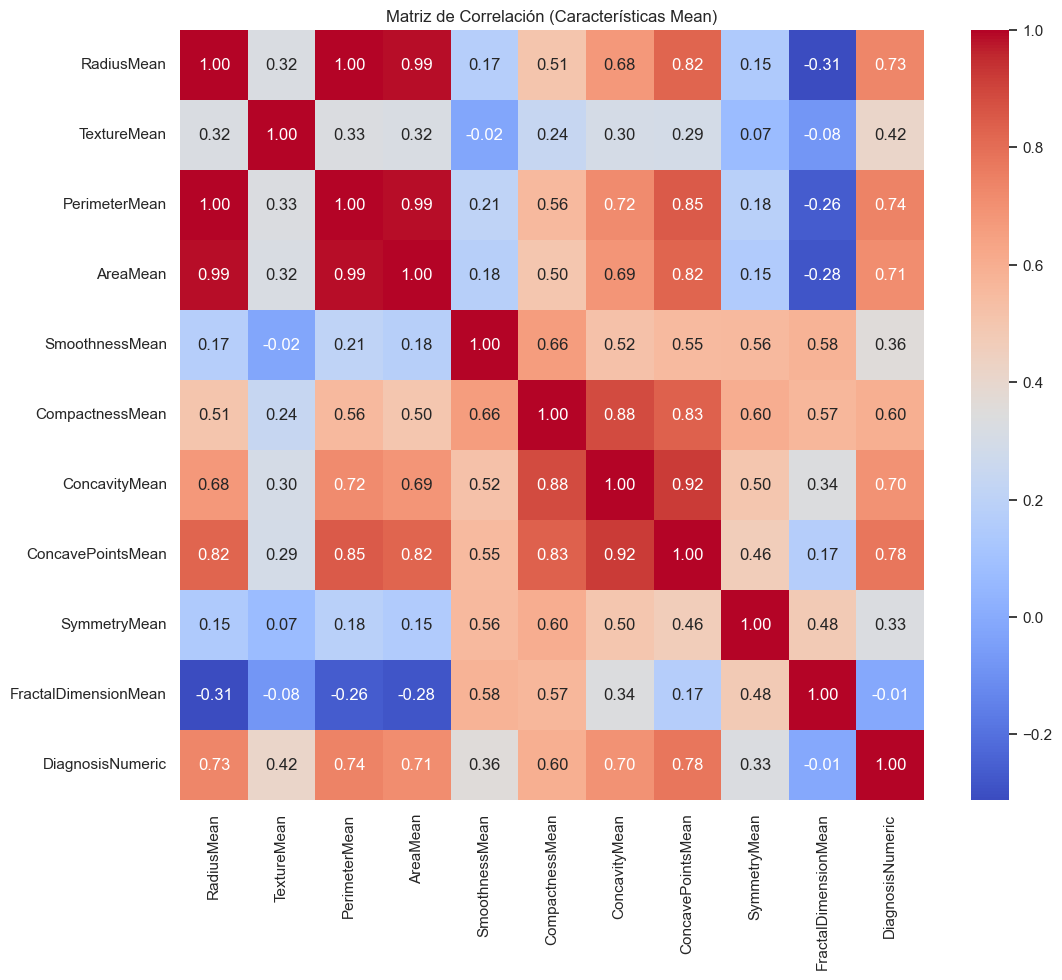

In [26]:
plt.figure(figsize=(12,10))
# Correlación de las primeras 10 características + el diagnóstico numérico
corr_matrix = df[features_mean + ['DiagnosisNumeric']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (Características Mean)')
plt.show()

14. Desarrollo de Gráficos Adicionales

**¿Qué otro tipo de gráficos pueden ser realizados para entender mejor los datos?**

Para profundizar en el análisis de este dataset médico, implemento visualizaciones avanzadas que permiten identificar patrones de separación entre tumores benignos (B) y malignos (M).

14.1. PairPlot: Relaciones Multidimensionales

El PairPlot permite observar las relaciones de dispersión entre múltiples pares de variables simultáneamente, además de la distribución de cada una en la diagonal. Esto es fundamental para identificar qué variables separan mejor las clases

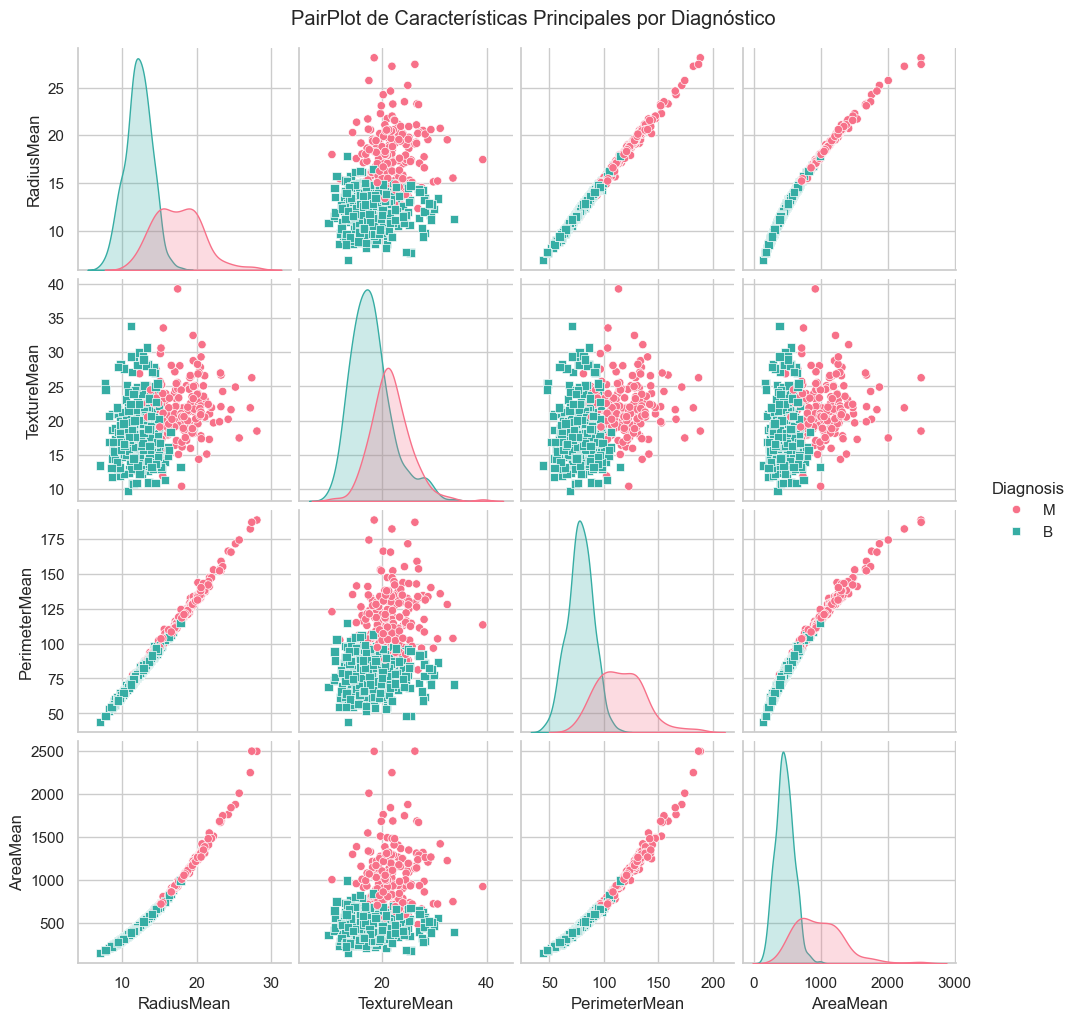

In [27]:
# Seleccionamos un subconjunto de características "Mean" para que el gráfico sea legible
subset_features = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'Diagnosis']

sns.pairplot(df[subset_features], hue='Diagnosis', palette='husl', markers=["o", "s"])
plt.suptitle("PairPlot de Características Principales por Diagnóstico", y=1.02)
plt.show()

14.2. JointPlot: Relación entre Área y Perímetro

Se utiliza un JointPlot para analizar dos variables que tienen una alta correlación geométrica: el área y el perímetro. Este gráfico incluye las distribuciones marginales (histogramas/KDE) en los ejes.

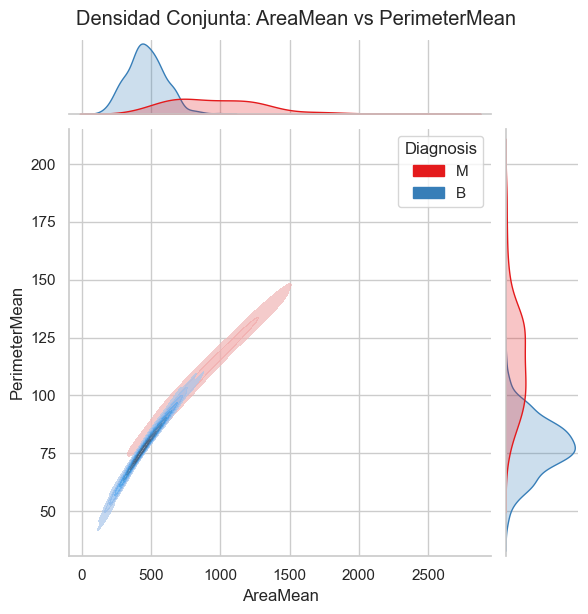

In [28]:
# Analizamos la relación entre Area y Perimetro con sus densidades marginales
g = sns.jointplot(data=df, x="AreaMean", y="PerimeterMean", hue="Diagnosis", 
                  kind="kde", fill=True, alpha=0.7, palette='Set1')
g.fig.suptitle("Densidad Conjunta: AreaMean vs PerimeterMean", y=1.02)
plt.show()

14.3. Scatter Plot con Línea de Regresión

Para identificar dependencias directas y ver cómo cambia la tendencia según el diagnóstico, graficamos el radio contra los puntos cóncavos (característica clave en la detección de cáncer).

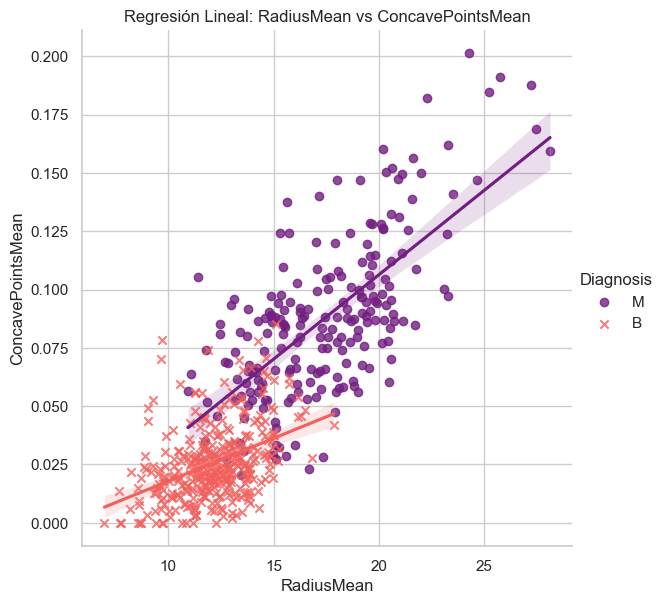

In [29]:
# Scatter plot con regresión lineal para observar la tendencia
sns.lmplot(data=df, x="RadiusMean", y="ConcavePointsMean", hue="Diagnosis", 
           palette='magma', markers=["o", "x"], height=6)
plt.title("Regresión Lineal: RadiusMean vs ConcavePointsMean")
plt.show()

14.4. PCA (Análisis de Componentes Principales)

Dado que el dataset tiene 30 características, es difícil visualizarlo todo en una sola imagen. El PCA reduce la dimensionalidad a los dos componentes que capturan la mayor variabilidad de los datos, permitiendo ver si los grupos son linealmente separables en un plano 2D.

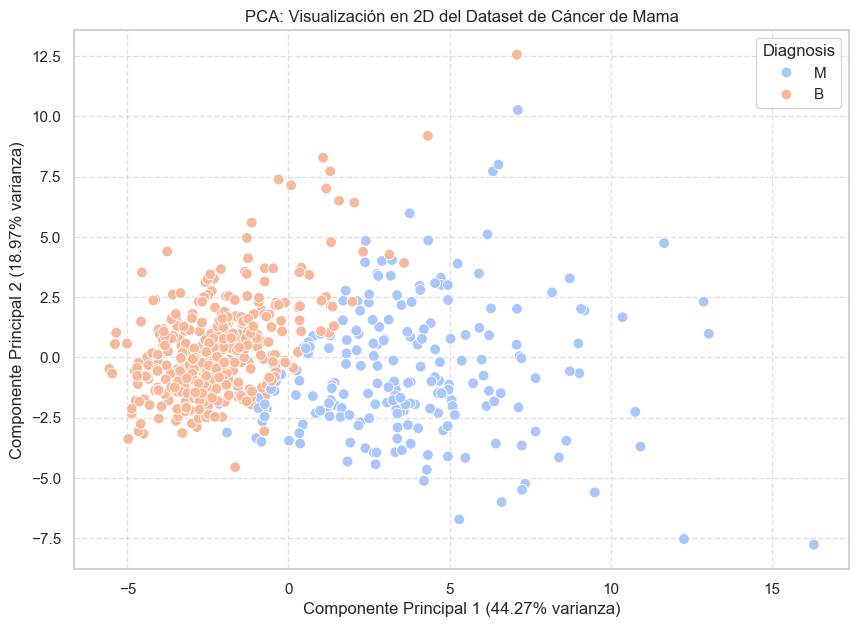

In [34]:
from sklearn.decomposition import PCA

# 1. Preparar los datos (usamos el dataframe normalizado df_norm del paso 8)
# Excluimos Id, Diagnosis y DiagnosisNumeric para el cálculo
X = df_norm.drop(['Id', 'Diagnosis', 'DiagnosisNumeric'], axis=1)

# 2. Aplicar PCA para 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# 3. Crear un nuevo DataFrame con los componentes
df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['Diagnosis'] = df['Diagnosis'].values

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Diagnosis', palette='coolwarm', s=60)
plt.title('PCA: Visualización en 2D del Dataset de Cáncer de Mama')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Descripción Final de los Gráficos Extra:

* PairPlot: Revela que características como AreaMean y RadiusMean muestran una separación casi lineal entre las etiquetas B y M.

* JointPlot: Confirma que los tumores malignos tienden a concentrarse en valores mucho más altos de área y perímetro, con densidades muy distintas a los benignos.

* Scatter Plot (Regresión): La pendiente de la relación entre el radio y los puntos cóncavos es más pronunciada en tumores malignos, indicando una mayor complejidad celular a medida que crece el tamaño.

* PCA: Es la prueba definitiva de que los datos están bien estructurados. Al ver dos clusters claramente diferenciados en el plano, podemos concluir que un modelo de aprendizaje automático (como Regresión Logística o SVM) tendría un alto desempeño clasificando estos datos.